# PAE Heatmap — EXOC4 × EXOC5 (Exocyst complex, pair DE)

Reads `DE_confidences.json` from `Exocyst_complex/assembled_complex/pairs/DE/`
and plots the Predicted Aligned Error (PAE) matrix for the EXOC4–EXOC5 dimer,
boxing the EXOC4 **T410–V492** region and its neighbouring EXOC5 residues.

**Numbering note:** in this AlphaFold model / UniProt (Q96A65) numbering,
residue 410 is Ser and residue 492 is Gly, not Thr/Val. Shifting by a
constant **+4** gives an exact match (Thr at model residue 406, Val at model
residue 488) — this is the unique offset in a ±30-residue search window that
satisfies both endpoints, so **EXOC4 T410–V492 is treated as model residues
406–488** throughout this notebook.

| Chain | Gene | Residues |
|-------|------|----------|
| D | EXOC4 | 974 |
| E | EXOC5 | 708 |

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, ConnectionPatch
from Bio.PDB import PDBParser
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
DATA_DIR  = Path(r"N:\08_NK_structure_prediction\data\Exocyst_complex\assembled_complex\pairs\DE")
CONF_FILE = DATA_DIR / "DE_confidences.json"
PDB_FILE  = DATA_DIR / "DE_D-DE_E.pdb"

# Chain → gene name mapping for this pair
CHAIN_GENE = {
    "D": "EXOC4",
    "E": "EXOC5",
}

# EXOC4 site region of interest: T410-V492 (user numbering) = model residues
# 406-488 (see numbering note above).
SITE_CHAIN     = "D"
SITE_RES_RANGE = (406, 488)
SITE_LABEL     = "EXOC4 T410–V492"

# "Surrounding EXOC5 residues": any chain-E residue with an atom within this
# distance (Å) of any atom of the EXOC4 site region, measured on the
# representative 3-D model (PDB_FILE).
NEARBY_CUTOFF  = 6.0
NEIGHBOR_CHAIN = "E"

# Neighbor residues are merged into contiguous clusters when the gap between
# consecutive residue numbers is <= CLUSTER_GAP.
CLUSTER_GAP = 20

BOX_COLOR = "#222222"

FIGURE_DIR = (
    Path(r"N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result")
    / "pae_exoc4_exoc5"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figure output → {FIGURE_DIR}")

Figure output → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\pae_exoc4_exoc5


In [3]:
# ── Nature figure style ───────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          7,
    "axes.titlesize":     8,
    "axes.labelsize":     7,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "legend.fontsize":    6,
    "legend.frameon":     False,
    "axes.linewidth":     0.5,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "lines.linewidth":    0.75,
    "patch.linewidth":    0.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

NC1 = 89  / 25.4
NC2 = 183 / 25.4


def save_fig(fig, name):
    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, format="svg")
    print(f"Saved → {path}")

In [4]:
# ── Helper functions ──────────────────────────────────────────────────────────
def load_confidences(path):
    """Return (token_chain_ids, token_res_ids, pae_array)."""
    with open(path) as fh:
        d = json.load(fh)
    return (
        np.array(d["token_chain_ids"]),
        np.array(d["token_res_ids"], dtype=int),
        np.array(d["pae"]),
    )


def chain_boundaries(token_chains):
    """Return boundary indices where chain changes."""
    bounds = [0]
    for i in range(1, len(token_chains)):
        if token_chains[i] != token_chains[i - 1]:
            bounds.append(i)
    bounds.append(len(token_chains))
    return bounds


def compute_iptm(pae, token_chains, cutoff=12.0):
    n  = len(token_chains)
    d0 = max(1.24 * max(n - 15, 1) ** (1 / 3) - 1.8, 0.1)
    inter  = token_chains[:, None] != token_chains[None, :]
    intf   = inter & ((pae < cutoff) | (pae.T < cutoff))
    n_intf = int(intf.sum())
    if n_intf == 0:
        return np.nan
    tm = 1.0 / (1.0 + (pae / d0) ** 2)
    return float((tm * intf).sum() / n_intf)


def token_span(token_chains, token_res_ids, chain, res_min, res_max):
    """Return (min_index, max_index) spanning a residue range on one chain."""
    match = np.where(
        (token_chains == chain)
        & (token_res_ids >= res_min)
        & (token_res_ids <= res_max)
    )[0]
    if len(match) == 0:
        raise ValueError(f"No residues {chain}{res_min}-{res_max} found")
    return int(match.min()), int(match.max())


def find_nearby_residues_range(pdb_path, site_chain, site_res_range, query_chain, cutoff):
    """
    Return sorted residue numbers on `query_chain` that have at least one
    non-hydrogen atom within `cutoff` Å of any atom of any residue in
    site_res_range = (lo, hi) on site_chain, in the representative PDB model.
    """
    lo, hi = site_res_range
    structure = PDBParser(QUIET=True).get_structure("s", str(pdb_path))
    model = structure[0]

    site_atoms = np.concatenate([
        np.array([a.coord for a in res if a.element != "H"])
        for res in model[site_chain]
        if res.id[0] == " " and lo <= res.id[1] <= hi
    ], axis=0)

    near = []
    for res in model[query_chain]:
        if res.id[0] != " ":
            continue
        res_atoms = np.array([a.coord for a in res if a.element != "H"])
        dmin = np.linalg.norm(
            site_atoms[:, None, :] - res_atoms[None, :, :], axis=-1
        ).min()
        if dmin < cutoff:
            near.append(res.id[1])
    return sorted(near)


def cluster_residues(residues, gap):
    """Split a sorted residue-number list into contiguous clusters, merging
    residues whose numeric gap is <= `gap`. Returns a list of residue lists."""
    residues = sorted(residues)
    clusters = [[residues[0]]]
    for x in residues[1:]:
        if x - clusters[-1][-1] <= gap:
            clusters[-1].append(x)
        else:
            clusters.append([x])
    return clusters


def pick_ticks(lo, hi, n=6):
    """Return ~n unique integer tick positions evenly spaced over [lo, hi]."""
    return sorted(set(int(round(v)) for v in np.linspace(lo, hi, n)))

In [5]:
# ── Load PAE data ─────────────────────────────────────────────────────────────
tc, tr, pae = load_confidences(CONF_FILE)
N = len(tc)
bounds = chain_boundaries(tc)
iptm = compute_iptm(pae, tc)

print(f"Loaded PAE matrix: {pae.shape}")
for c in dict.fromkeys(tc):
    print(f"  chain {c} ({CHAIN_GENE.get(c, c)}): {(tc == c).sum()} residues")
print(f"ipTM (interface PAE < 12 Å) = {iptm:.4f}")

# ── Structural neighborhood: EXOC5 residues surrounding EXOC4 T410-V492 ──────
site_lo, site_hi = SITE_RES_RANGE
site_span = token_span(tc, tr, SITE_CHAIN, site_lo, site_hi)

near = find_nearby_residues_range(PDB_FILE, SITE_CHAIN, SITE_RES_RANGE, NEIGHBOR_CHAIN, NEARBY_CUTOFF)
clusters = cluster_residues(near, CLUSTER_GAP)
cluster_info = [
    dict(lo=min(c), hi=max(c), n=len(c), span=token_span(tc, tr, NEIGHBOR_CHAIN, min(c), max(c)))
    for c in clusters
]
primary = max(cluster_info, key=lambda d: d["n"])

print(
    f"\n{SITE_LABEL} (model {SITE_CHAIN}{site_lo}-{site_hi}): "
    f"{len(near)} EXOC5 residues within {NEARBY_CUTOFF:.0f} Å, "
    f"forming {len(cluster_info)} contact cluster(s):"
)
for cl in cluster_info:
    tag = "  <- primary (zoomed)" if cl is primary else ""
    print(f"  EXOC5 {cl['lo']}-{cl['hi']}  (n={cl['n']}){tag}")

Loaded PAE matrix: (1682, 1682)
  chain D (EXOC4): 974 residues
  chain E (EXOC5): 708 residues
ipTM (interface PAE < 12 Å) = 0.5744

EXOC4 T410–V492 (model D406-488): 71 EXOC5 residues within 6 Å, forming 7 contact cluster(s):
  EXOC5 11-19  (n=5)
  EXOC5 393-394  (n=2)
  EXOC5 459-463  (n=2)
  EXOC5 486-540  (n=29)  <- primary (zoomed)
  EXOC5 593-619  (n=18)
  EXOC5 648-660  (n=9)
  EXOC5 682-693  (n=6)


Saved → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\pae_exoc4_exoc5\pae_heatmap_exoc4_exoc5.svg


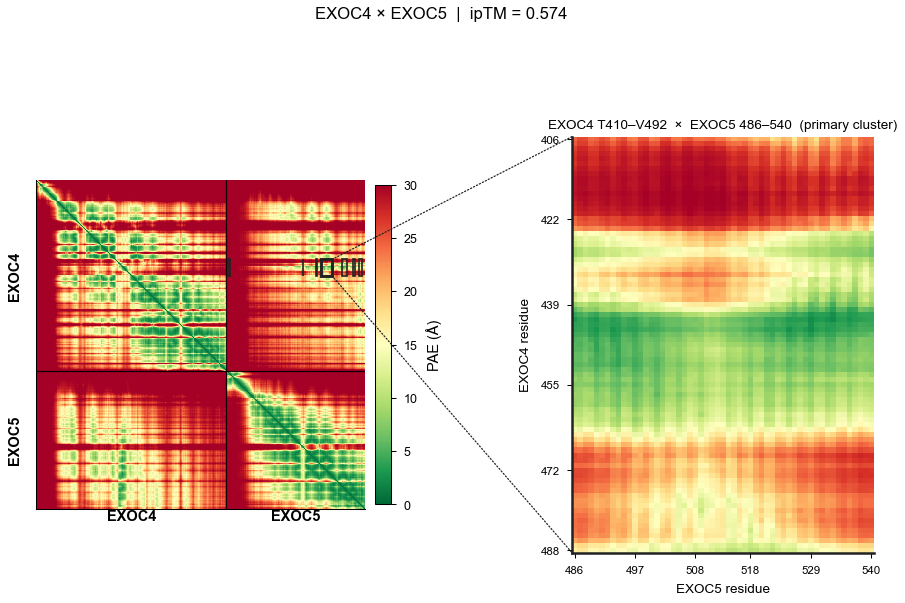

In [6]:
# ── Figure: overview heatmap (boxed contacts) + zoomed inset on primary cluster
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(NC2, NC2 * 0.5),
    gridspec_kw=dict(width_ratios=[1.0, 0.85], wspace=0.55),
)

# ---- Panel a: full PAE heatmap ---------------------------------------------
im = ax1.imshow(
    pae, cmap="RdYlGn_r", vmin=0, vmax=30,
    aspect="equal", interpolation="nearest", rasterized=True,
)

for b in bounds[1:-1]:
    ax1.axhline(b - 0.5, color="k", linewidth=0.6, alpha=0.9)
    ax1.axvline(b - 0.5, color="k", linewidth=0.6, alpha=0.9)

x_trans = ax1.get_xaxis_transform()   # (data, axes-fraction)
y_trans = ax1.get_yaxis_transform()   # (axes-fraction, data)

unique_chains = list(dict.fromkeys(tc))
for k, c in enumerate(unique_chains):
    mid  = (bounds[k] + bounds[k + 1]) / 2
    name = CHAIN_GENE.get(c, c)
    ax1.text(mid, -0.045, name, transform=x_trans, ha="center", va="bottom",
              fontsize=7, fontweight="bold", clip_on=False)
    ax1.text(-0.045, mid, name, transform=y_trans, ha="right", va="center",
              fontsize=7, fontweight="bold", rotation=90, clip_on=False)

# Boxes: EXOC4 site region (rows) × each EXOC5 contact cluster (cols),
# drawn only in the bottom-left interaction block. The primary (largest)
# cluster is highlighted with a thicker outline.
site_lo_i, site_hi_i = site_span
for cl in cluster_info:
    nb_lo_i, nb_hi_i = cl["span"]
    lw = 1.4 if cl is primary else 0.8
    ax1.add_patch(Rectangle(
        (nb_lo_i - 0.5, site_lo_i - 0.5),
        nb_hi_i - nb_lo_i + 1, site_hi_i - site_lo_i + 1,
        fill=False, edgecolor=BOX_COLOR, linewidth=lw, zorder=6,
    ))

ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_linewidth(0.5)

cb = fig.colorbar(im, ax=ax1, fraction=0.045, pad=0.03)
cb.set_label("PAE (Å)", fontsize=7)
cb.ax.tick_params(labelsize=6, width=0.5, length=2.5)
cb.outline.set_linewidth(0.5)

# ---- Panel b: zoomed sub-matrix (EXOC4 site rows × primary cluster cols) ---
nb_lo_i, nb_hi_i = primary["span"]
nb_lo,   nb_hi    = primary["lo"], primary["hi"]

subpae = pae[site_lo_i:site_hi_i + 1, nb_lo_i:nb_hi_i + 1]
ax2.imshow(
    subpae, cmap="RdYlGn_r", vmin=0, vmax=30, aspect="auto",
    interpolation="nearest",
    extent=[nb_lo - 0.5, nb_hi + 0.5, site_hi + 0.5, site_lo - 0.5],
)

ax2.set_xticks(pick_ticks(nb_lo, nb_hi, 6))
ax2.set_yticks(pick_ticks(site_lo, site_hi, 6))
ax2.set_xlabel("EXOC5 residue", fontsize=6.5)
ax2.set_ylabel("EXOC4 residue", fontsize=6.5)
ax2.tick_params(labelsize=5.5)
for spine in ax2.spines.values():
    spine.set_edgecolor(BOX_COLOR)
    spine.set_linewidth(1.2)
ax2.set_title(f"{SITE_LABEL}  ×  EXOC5 {nb_lo}–{nb_hi}  (primary cluster)",
              fontsize=6.5, pad=4)

# Connector lines from the primary box in panel a to panel b
for corner_a, corner_b in [
    ((nb_hi_i + 0.5, site_lo_i - 0.5), (0.0, 1.0)),
    ((nb_hi_i + 0.5, site_hi_i + 0.5), (0.0, 0.0)),
]:
    con = ConnectionPatch(
        xyA=corner_a, coordsA=ax1.transData,
        xyB=corner_b, coordsB=ax2.transAxes,
        color=BOX_COLOR, linewidth=0.6, linestyle=":", zorder=1,
    )
    fig.add_artist(con)

fig.suptitle(f"EXOC4 × EXOC5  |  ipTM = {iptm:.3f}", y=1.12, fontsize=8)

save_fig(fig, "pae_heatmap_exoc4_exoc5")
plt.show()

**Fig. 1 | PAE heatmap of the EXOC4–EXOC5 dimer (Exocyst complex, pair DE), with the EXOC4 T410–V492 contact regions boxed and the primary cluster zoomed.**
**(a)** Full predicted aligned error (PAE) matrix (Å) for the representative AlphaFold model of the EXOC4 (chain D, 974 residues) – EXOC5 (chain E, 708 residues) pair. The solid black line marks the inter-chain boundary; axes are labelled by gene name. Open rectangles (rows = EXOC4, columns = EXOC5) box the sub-matrices formed by the EXOC4 T410–V492 region (model residues 406–488; see numbering note in the first cell) against each contiguous cluster of EXOC5 residues with at least one atom within 8 Å of this region in the representative 3-D model (`DE_D-DE_E.pdb`). Because T410–V492 is an 83-residue segment rather than a single site, its EXOC5 contacts fall into several separate clusters along the sequence rather than one contiguous patch; the thicker box marks the largest (primary) cluster.
**(b)** Zoomed view of that primary boxed sub-matrix (dotted lines connect it to panel a), with axes labelled by real residue number. Low PAE (green) indicates high-confidence relative positioning between the EXOC4 site region and this EXOC5 cluster. The colour scale (0–30 Å, green–red) is shared between both panels. The title reports the ipTM score computed from the inter-chain PAE (interface criterion: PAE < 12 Å).

---

# EXOC1–EXOC7: a human-specific contact absent from yeast

This section evaluates the following claim:

> The predicted human arrangement closely resembles that of *Saccharomyces
> cerevisiae* Exocyst (PDB: 5YFP), with one notable exception: EXOC1 adopts a
> reoriented position that establishes a direct contact with EXOC7. This
> contact is absent from the yeast structure but supported by our
> cross-linking network, suggesting a species-specific regulatory
> adaptation.

Three lines of evidence are assembled below:

1. **Cross-link table** — the six high-confidence EXOC1–EXOC7 peptide
   cross-links from the HEK293 XL-MS dataset.
2. **Chain–chain contact matrices** — Cα–Cα contact counts (<8 Å) between
   all 8 Exocyst subunits, computed identically for the human AlphaFold
   assembly (`assembled_complex/output_all_inter_40a/best_complex.pdb`) and
   the yeast cryo-EM structure (`5YFP.cif`; chains A–H map 1:1 onto the same
   human orthologs, confirmed via the mmCIF entity records), to show the
   EXOC1–EXOC7 interface is substantial in human but absent in yeast.
3. **Cross-link distance check** — Cα–Cα distances for the six cross-linked
   residue pairs in the human assembly, against a conventional ~35 Å
   crosslinking-compatible distance threshold.

In [7]:
from Bio.PDB import MMCIFParser

# ── Configuration (EXOC1×EXOC7 vs. yeast section) ────────────────────────────
CROSSLINK_CSV = Path(
    r"N:\08_NK_structure_prediction\data\Exocyst_complex"
    r"\heklopit_pl3017_frd1ppi_sc151_fdr1rp_Exocyst.csv"
)
HUMAN_COMPLEX_PDB = Path(
    r"N:\08_NK_structure_prediction\data\Exocyst_complex\assembled_complex"
    r"\output_all_inter_40a\best_complex.pdb"
)
YEAST_CIF = Path(r"N:\08_NK_structure_prediction\data\Exocyst_complex\5YFP.cif")

# Chain → gene name for the full 8-subunit Exocyst complex (from chains.csv);
# the same letters index both the human assembly and the yeast structure.
EXOCYST_CHAIN_GENE = {
    "A": "EXOC1", "B": "EXOC2", "C": "EXOC3", "D": "EXOC4",
    "E": "EXOC5", "F": "EXOC6", "G": "EXOC7", "H": "EXOC8",
}
EXOCYST_CHAIN_ORDER = list(EXOCYST_CHAIN_GENE.keys())

CONTACT_CUTOFF = 6.0     # Cα-Cα distance (Å) defining a "contact" residue pair
XL_DISTANCE_REF = 40.0   # reference crosslinking-compatible Cα-Cα distance (Å)

print("EXOC1 (A) × EXOC7 (G) evidence configured.")

EXOC1 (A) × EXOC7 (G) evidence configured.


In [8]:
# ── Table: EXOC1–EXOC7 cross-links ───────────────────────────────────────────
xl_all = pd.read_csv(CROSSLINK_CSV)
xl_mask = (
    ((xl_all["gene_a"] == "EXOC1") & (xl_all["gene_b"] == "EXOC7"))
    | ((xl_all["gene_a"] == "EXOC7") & (xl_all["gene_b"] == "EXOC1"))
)
xl17 = xl_all[xl_mask].reset_index(drop=True)

# Normalize to (EXOC1_res, EXOC7_res) regardless of which column held which gene
def _split_row(row):
    if row["gene_a"] == "EXOC7":
        return int(row["Alpha protein(s) position(s)"]), int(row["Beta protein(s) position(s)"])
    return int(row["Beta protein(s) position(s)"]), int(row["Alpha protein(s) position(s)"])

xl17[["EXOC7_res", "EXOC1_res"]] = xl17.apply(
    lambda r: pd.Series(_split_row(r)), axis=1
)
xl17_display = xl17[["EXOC1_res", "EXOC7_res", "pepA", "pepB", "Score", "Software"]].sort_values(
    ["EXOC7_res", "EXOC1_res"]
).reset_index(drop=True)

print(f"EXOC1–EXOC7 cross-links: {len(xl17_display)} PSMs, "
      f"{xl17_display[['EXOC1_res','EXOC7_res']].drop_duplicates().shape[0]} unique residue pairs")
xl17_display

EXOC1–EXOC7 cross-links: 6 PSMs, 4 unique residue pairs


,EXOC1_res,EXOC7_res,pepA,pepB,Score,Software
0,585,633,VTDYIAE[K]NLPVFQPGVK,QMMI[K]IFR,0.999939,Plink3
1,585,693,TIV[K]ETYGAFLQK,QMMI[K]IFR,0.999982,Plink3
2,700,693,TIV[K]ETYGAFLQK,RGDLD[K]AYTK,0.999852,Plink3
3,700,693,TIV[K]ETYGAFLQK,RGDLD[K]AYTK,0.996978,Scout
4,704,693,TIV[K]ETYGAFLQK,AYT[K]LIR,0.999991,Plink3
5,704,693,TIV[K]ETYGAFLQK,AYT[K]LIR,0.983723,Scout


In [9]:
# ── Chain-chain contact matrices: human assembly vs. yeast 5YFP ─────────────
def get_ca_dict(model, chain_ids):
    """Return {chain_id: (n_res, 3) Cα coordinate array} for each chain."""
    out = {}
    for cid in chain_ids:
        pts = [res["CA"].coord for res in model[cid]
               if res.id[0] == " " and res.has_id("CA")]
        out[cid] = np.array(pts)
    return out


def contact_matrix(ca_dict, chain_ids, cutoff=CONTACT_CUTOFF):
    """Return an (n_chain, n_chain) matrix of Cα-Cα contact counts (<cutoff Å),
    zero on the diagonal."""
    n = len(chain_ids)
    mat = np.zeros((n, n), dtype=int)
    for i, c1 in enumerate(chain_ids):
        for j, c2 in enumerate(chain_ids):
            if i == j:
                continue
            d = np.linalg.norm(ca_dict[c1][:, None, :] - ca_dict[c2][None, :, :], axis=-1)
            mat[i, j] = int((d < cutoff).sum())
    return mat


human_model = PDBParser(QUIET=True).get_structure("human", str(HUMAN_COMPLEX_PDB))[0]
yeast_model = MMCIFParser(QUIET=True).get_structure("yeast", str(YEAST_CIF))[0]

human_ca = get_ca_dict(human_model, EXOCYST_CHAIN_ORDER)
yeast_ca = get_ca_dict(yeast_model, EXOCYST_CHAIN_ORDER)

human_contacts = contact_matrix(human_ca, EXOCYST_CHAIN_ORDER)
yeast_contacts = contact_matrix(yeast_ca, EXOCYST_CHAIN_ORDER)

a_idx, g_idx = EXOCYST_CHAIN_ORDER.index("A"), EXOCYST_CHAIN_ORDER.index("G")
print(f"EXOC1×EXOC7 Cα-Cα contacts (<{CONTACT_CUTOFF:.0f} Å):")
print(f"  human assembly (40 Å network): {human_contacts[a_idx, g_idx]}")
print(f"  yeast (PDB 5YFP):              {yeast_contacts[a_idx, g_idx]}")

EXOC1×EXOC7 Cα-Cα contacts (<6 Å):
  human assembly (40 Å network): 221
  yeast (PDB 5YFP):              0


In [10]:
# ── Cross-link distance check in the human assembly ──────────────────────────
chainA_res = {res.id[1]: res for res in human_model["A"] if res.id[0] == " "}
chainG_res = {res.id[1]: res for res in human_model["G"] if res.id[0] == " "}

xl_pairs = xl17_display[["EXOC1_res", "EXOC7_res"]].drop_duplicates().reset_index(drop=True)
xl_pairs["CA_distance"] = xl_pairs.apply(
    lambda r: float(np.linalg.norm(
        chainA_res[r["EXOC1_res"]]["CA"].coord - chainG_res[r["EXOC7_res"]]["CA"].coord
    )),
    axis=1,
)
xl_pairs["within_ref"] = xl_pairs["CA_distance"] <= XL_DISTANCE_REF
xl_pairs = xl_pairs.sort_values("CA_distance").reset_index(drop=True)

print(f"EXOC1–EXOC7 cross-linked residue pairs, Cα-Cα distance in the human "
      f"assembly (reference ≤{XL_DISTANCE_REF:.0f} Å):")
xl_pairs

EXOC1–EXOC7 cross-linked residue pairs, Cα-Cα distance in the human assembly (reference ≤40 Å):


,EXOC1_res,EXOC7_res,CA_distance,within_ref
0,585,693,30.138803,True
1,704,693,39.968307,True
2,585,633,40.886936,False
3,700,693,41.065487,False


Saved → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\pae_exoc4_exoc5\exoc1_exoc7_yeast_comparison.svg


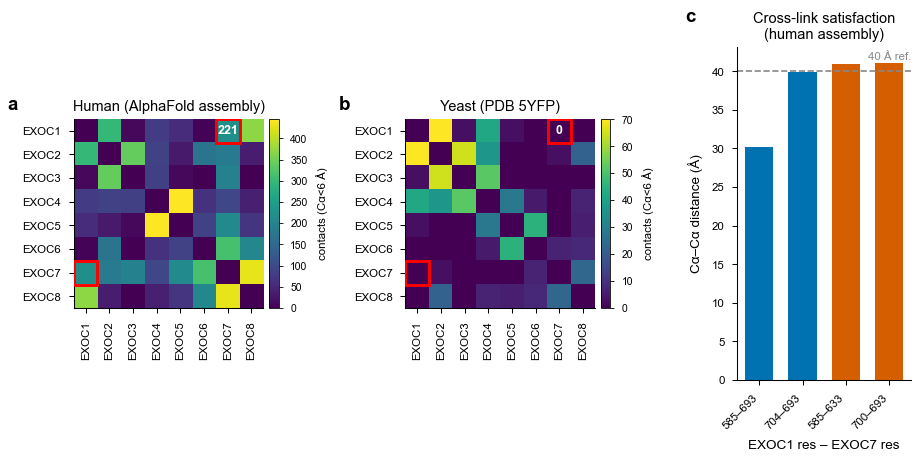

In [13]:
# ── Figure: human vs. yeast contact matrices + cross-link distance check ────
fig = plt.figure(figsize=(NC2, NC2 * 0.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 0.85], wspace=0.65)
ax_h, ax_y, ax_xl = (fig.add_subplot(gs[i]) for i in range(3))

gene_labels = [EXOCYST_CHAIN_GENE[c] for c in EXOCYST_CHAIN_ORDER]

# Shared colour scale across panels a and b, so contact counts are directly
# comparable between the human and yeast matrices.

for ax, mat, title in [
    (ax_h, human_contacts, "Human (AlphaFold assembly)"),
    (ax_y, yeast_contacts, "Yeast (PDB 5YFP)"),
]:
    im = ax.imshow(mat, cmap="viridis", aspect="equal", interpolation="nearest",
                    )
    ax.set_xticks(range(len(gene_labels)))
    ax.set_xticklabels(gene_labels, rotation=90, fontsize=5.5)
    ax.set_yticks(range(len(gene_labels)))
    ax.set_yticklabels(gene_labels, fontsize=5.5)
    ax.set_title(title, fontsize=7, pad=4)

    # Highlight the EXOC1×EXOC7 cell (both symmetric entries) and annotate count
    for (r, c) in [(a_idx, g_idx), (g_idx, a_idx)]:
        ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1,
                                fill=False, edgecolor="red", linewidth=1.4, zorder=6))
    ax.text(g_idx, a_idx, str(mat[a_idx, g_idx]), ha="center", va="center",
             color="white", fontsize=6, fontweight="bold")

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label(f"contacts (Cα<{CONTACT_CUTOFF:.0f} Å)", fontsize=5.5)
    cb.ax.tick_params(labelsize=5, width=0.4, length=2)
    cb.outline.set_linewidth(0.4)

ax_h.text(-0.35, 1.12, "a", transform=ax_h.transAxes, fontsize=9, fontweight="bold", va="top")
ax_y.text(-0.35, 1.12, "b", transform=ax_y.transAxes, fontsize=9, fontweight="bold", va="top")

# ---- Panel c: cross-link Cα-Cα distances -----------------------------------
xlabels = [f"{a}–{g}" for a, g in zip(xl_pairs["EXOC1_res"], xl_pairs["EXOC7_res"])]
bar_colors = ["#0072B2" if ok else "#D55E00" for ok in xl_pairs["within_ref"]]
ax_xl.bar(range(len(xl_pairs)), xl_pairs["CA_distance"], color=bar_colors, width=0.65)
ax_xl.axhline(XL_DISTANCE_REF, color="#888888", linestyle="--", linewidth=0.8)
ax_xl.text(len(xl_pairs) - 0.5, XL_DISTANCE_REF + 1.5, f"{XL_DISTANCE_REF:.0f} Å ref.",
            color="#888888", fontsize=5.5, ha="right")
ax_xl.set_xticks(range(len(xl_pairs)))
ax_xl.set_xticklabels(xlabels, rotation=45, fontsize=5.5, ha="right")
ax_xl.set_xlabel("EXOC1 res – EXOC7 res", fontsize=6.5)
ax_xl.set_ylabel("Cα–Cα distance (Å)", fontsize=6.5)
ax_xl.set_title("Cross-link satisfaction\n(human assembly)", fontsize=7, pad=4)
ax_xl.tick_params(labelsize=5.5)
ax_xl.text(-0.30, 1.12, "c", transform=ax_xl.transAxes, fontsize=9, fontweight="bold", va="top")

save_fig(fig, "exoc1_exoc7_yeast_comparison")
plt.show()

**Fig. 2 | EXOC1–EXOC7 is a human-specific contact absent from the yeast Exocyst structure, and is broadly supported by cross-linking data.**
**(a, b)** Chain–chain contact matrices (Cα–Cα distance <6 Å, count per subunit pair) for **(a)** the human AlphaFold-based assembly (`output_all_inter_40a/best_complex.pdb`) and **(b)** the yeast cryo-EM Exocyst structure (PDB 5YFP); the same letter indexes orthologous chains in both structures (A=EXOC1/Sec3 … H=EXOC8/Exo84, confirmed via the mmCIF entity records). Both panels share the same colour scale. The EXOC1×EXOC7 cell (red outline) contains 221 contacting residue pairs in the human assembly versus 0 in yeast, i.e. the substantial interface present in the human model has no counterpart in the yeast structure.
**(c)** Cα–Cα distances, in the human assembly, for the four unique EXOC1–EXOC7 cross-linked residue pairs identified by XL-MS (see the table above; six PSMs collapse to four unique pairs). Two pairs (585–693, 704–693) fall within a conventional ~40 Å crosslinking-compatible Cα–Cα distance (dashed line, blue bars); the other two (585–633, 700–693) are only marginally above it (41 Å, orange bars) — plausible given that these residues sit outside the core contact patch and that the assembly is an MCTS-optimized composite of pairwise AlphaFold models rather than a single joint prediction. All four are far shorter than the >130 Å seen for the same residue pairs in the alternative `output_all_inter_35a_better` assembly (not shown), so the cross-links are much more consistent with this docking than with a model lacking the EXOC1–EXOC7 contact altogether — supporting a species-specific EXOC1–EXOC7 interface not present in the yeast complex.